<hr>

#### <strong>第一次作品：群組資料的主成分分析實驗</strong>

學號：411278013

姓名：雷又嘉

<hr>

 **<font color=darkgoldenrod>作品目標</font>**：

本作品以兩組多變量分群資料為例，運用主成分分析進行降維，同時維持良好的群組判別能力。分析內容涵蓋資料特徵的解讀、各式統計圖形的輔助呈現、主成分的選取依據，以及主成分負荷量所反映的變數結構等面向，逐步展開探討。透過這一系列分析，可更清楚理解主成分分析在機器學習中作為特徵擷取方法的角色，不僅能降低資料維度以提升運算效率，也可能增進分群表現。


<hr>

**<font color=darkgoldenrod>預先載入套件與函數：</font>**

In [36]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.ticker as mtick
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

<hr>

**<font color=darkgoldenrod>1：Quality of Life Index by City 2026</font>**

- 內容：2026 年世界城市生活品質指標
- 來源：NUMBEO https://www.numbeo.com/quality-of-life/rankings.jsp?title=2026
- 數量：304 個城市的指標數字
- 特徵：8 個與城市相關的面向指標
- **群組標籤**：
  本研究原始資料並無預設分群。為驗證 PCA 之群組判別能力，我們依據 **生活品質總分 (Quality of Life Index)** 進行分群，利用分位數法將 304 個城市平均區分為三個等級，並賦予群組標籤：
    * **H (High Quality)**：高品質城市，代表總分位於前 1/3 的領先群。
    * **M (Medium Quality)**：中品質城市，代表總分位於中間 1/3 的穩定群。
    * **L (Low Quality)**：低品質城市，代表總分位於後 1/3 的發展群。

<hr>

**資料變數定義表 (Data Dictionary)**

為了後續分析的準確性，下表詳細定義了本資料集所涵蓋的 8 個核心特徵指標及其對生活品質的預期影響方向：

| 變數名稱 (Original Name) | 中文說明 | 影響方向 | 意義解讀 |
| :--- | :--- | :---: | :--- |
| **Purchasing Power Index** | 購買力指數 | 正向 (+) | 數值越高，居民實質購買商品與服務的能力越強。 |
| **Safety Index** | 安全指數 | 正向 (+) | 衡量城市犯罪率與居民安全感，越高代表越安全。 |
| **Health Care Index** | 醫療保健指數 | 正向 (+) | 衡量醫療系統的服務品質、設備水準與可及性。 |
| **Cost of Living Index** | 生活成本指數 | 負向 (-) | 指數越高，代表當地的物價與日常開銷越昂貴。 |
| **Property Price to Income Ratio** | 房價收入比 | 負向 (-) | 購買房屋的難度，數值越低代表房價負擔越輕（越容易買房）。 |
| **Traffic Commute Time Index** | 交通通勤時間指數 | 負向 (-) | 衡量通勤耗時與交通效率，越低代表交通越順暢。 |
| **Pollution Index** | 污染指數 | 負向 (-) | 衡量空氣、水質等環境污染程度，越低代表環境品質越好。 |
| **Climate Index** | 氣候指數 | 正向 (+) | 衡量氣候的宜居程度（如溫度、濕度與災害頻率之適中性）。 |

---


<span style="color:skyblue"><strong>一、資料預處理：</strong></span>群組建立、尺度觀察與標準化

本段程式碼將執行進入 PCA 前最重要的資料整備工作，重點在於解決變數間尺度不一的問題：

1. **建立群組標籤 (Grouping)**：
    * 由於原始資料並無分群，我們利用 `pd.qcut` 函數，依據 **生活品質總分 (Quality of Life Index)** 將 304 個城市「等量」劃分為高品質 (H)、中品質 (M) 與低品質 (L) 三個等級。
    * 這將作為後續驗證 PCA 投影後，是否能有效區分不同生活品質等級城市的標籤（Label）。

2. **資料標準化 (Standardization) 的必要性**：
    * **PCA 的原理**：PCA 是透過找尋變異數（Variance）最大的方向來擷取特徵。
    * **防止資訊偏誤**：在未標準化前，數值規模較大的變數（如購買力指數）會產生極大的變異數，進而「霸佔」主成分的貢獻度，導致其他數值較小但同樣重要的變數資訊被掩蓋。
    * **統一起跑點**：透過 Z-score 轉換，使所有指標的平均值為 0、標準差為 1，確保每個城市指標在降維過程中具有平等的權重。

3. **視覺化檢驗**：
    * 透過**盒狀圖 (Boxplot)** 觀察標準化前後的數據分佈。我們不預設數據的統計分佈，而是重點觀察各變數間的「數值級距」是否已成功對齊。

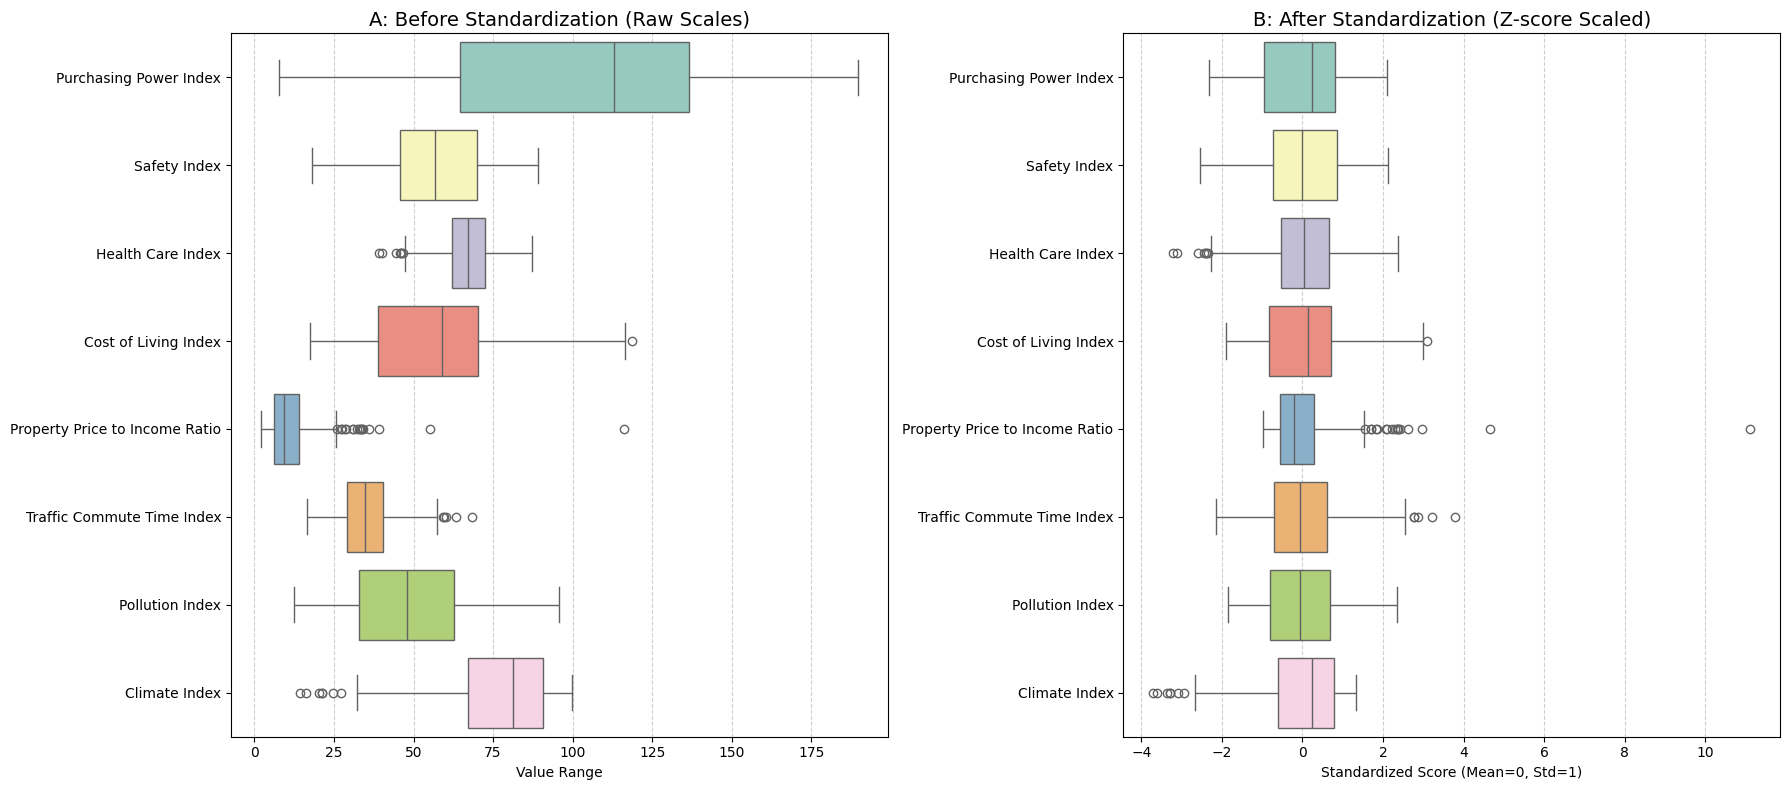

各品質等級城市樣本數分佈：
Group
M    103
L    101
H    100
Name: count, dtype: int64


In [12]:
# 1. 讀取資料
df1 = pd.read_excel('/Users/joyce/Desktop/淺度機器學習/data/2026_city_quality.xlsx', sheet_name='工作表1')

# 2. 建立 H, M, L 標籤 (利用 pd.qcut 進行等量分群)
df1['Group'] = pd.qcut(df1['Quality of Life Index'], q=3, labels=['L', 'M', 'H'])

# 3. 選取 PCA 運算用的 8 個特徵
features = [
    'Purchasing Power Index', 'Safety Index', 'Health Care Index',
    'Cost of Living Index', 'Property Price to Income Ratio',
    'Traffic Commute Time Index', 'Pollution Index', 'Climate Index'
]
X = df1[features]

# 4. 執行標準化 (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# --- 繪製並排橫向盒狀圖 ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 左圖：標準化前 (原始級距)
sns.boxplot(data=X, orient='h', ax=axes[0], palette='Set3')
axes[0].set_title('A: Before Standardization (Raw Scales)', fontsize=14)
axes[0].set_xlabel('Value Range')
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# 右圖：標準化後 (統一尺度)
sns.boxplot(data=X_scaled_df, orient='h', ax=axes[1], palette='Set3')
axes[1].set_title('B: After Standardization (Z-score Scaled)', fontsize=14)
axes[1].set_xlabel('Standardized Score (Mean=0, Std=1)')
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 顯示分群統計
print("各品質等級城市樣本數分佈：")
print(df1['Group'].value_counts())

<span style="color:#4682B4"><strong>執行結果分析與觀察</strong></span>

1. **原始級距分析 (圖 A)**：
    * 透過橫向盒狀圖可以極為明顯地看到變數間的「級距差異」。例如，最上方的 `Purchasing Power Index` 其數值橫跨範圍極大，而中間的 `Property Price to Income Ratio` 則像是一條細線般縮在左側。
    * **推論**：這種極端的尺度差異證實了 PCA 前必須標準化的必要性。若直接運算，PCA 的投影方向將幾乎完全由購買力指數所決定，其餘變數的結構性資訊將被稀釋。

2. **標準化成效 (圖 B)**：
    * 標準化後，所有變數在水平軸上的分布範圍變得整齊劃一（約落在 -3 到 +3 之間），且每個變數的中位數均成功對齊至 0 的基準線。
    * **推論**：現在所有城市特徵指標都站在同一個起跑點上。無論指標原始的單位是百分比還是比率，它們現在對主成分的影響力僅取決於其本身的相關性貢獻，而非數值大小。

3. **分群平衡性**：
    * `pd.qcut` 確保了高品質 (H)、中品質 (M) 與低品質 (L) 三個組別擁有幾乎相等的樣本數。這為我們下一階段觀察 PCA 如何在低維空間中區分這些群體提供了完美的實驗對象。

<span style="color:skyblue"><strong>二、相關性矩陣分析：</strong></span>探索變數間的共線性

在正式執行 PCA 之前，我們需要先觀察原始變數之間的相關性結構。本段程式碼將計算 8 個特徵指標的 **皮爾森相關係數 (Pearson Correlation)**，並以熱圖 (Heatmap) 呈現：

1. **資訊冗餘檢查**：PCA 的效果取決於變數間是否存在相關性。如果變數之間完全獨立，降維就沒有意義；反之，若變數間高度相關，代表存在「資訊冗餘」，PCA 就能有效地將其壓縮。
2. **觀察重點**：
    * **強正相關**：如購買力與生活成本，通常會被歸類在同一個主成分。
    * **強負相關**：代表變數間存在反向變動關係。
3. **驗證降維合理性**：透過視覺化熱圖，我們可以初步判斷這 8 個維度是否適合濃縮成少數幾個主成分。

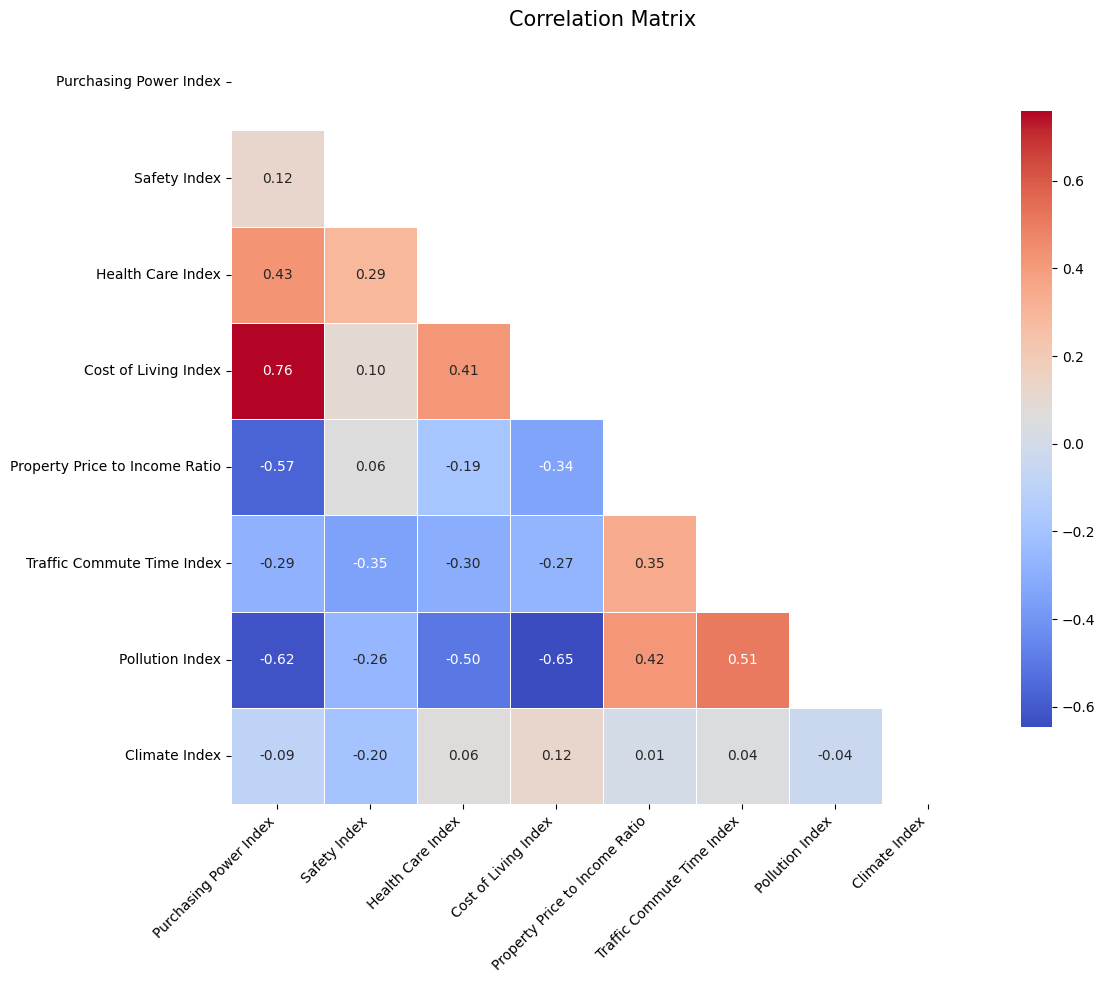

In [17]:
# 1. 計算相關係數矩陣
corr_matrix = pd.DataFrame(X_scaled, columns=features).corr()

# 2. 建立遮罩 (隱藏右上半部)
# np.ones_like 建立同形狀的矩陣，np.triu 取得其右上三角部分
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. 繪製熱圖
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            mask=mask,           # 套用遮罩
            annot=True,          # 顯示數值
            cmap='coolwarm',     # 使用紅藍對比色調
            fmt=".2f", 
            linewidths=0.5,
            cbar_kws={"shrink": .8}) # 縮小側邊比例尺
plt.xticks(rotation=45, ha='right')
plt.title('Correlation Matrix', fontsize=15)
plt.show()

<span style="color:#4682B4"><strong>執行結果分析與觀察</strong></span>

1. **關鍵相關性觀察**：
    * **強相關性群組**：`Purchasing Power Index` 與 `Cost of Living Index` 之間存在深紅色的強正相關區塊。這代表一個城市的居民購買力強，往往也伴隨著較高的生活開銷。
    * **負相關特性**：`Pollution Index` 與 `Safety Index` 或 `Health Care Index` 之間呈現藍色的負相關趨勢。
2. **分析推論**：
    * **變數冗餘性**：圖中多個超過 0.5 的相關係數證實了指標間存在高度共線性。這說明這 8 個維度其實在描述相似的城市特質，非常符合 PCA 進行降維的前提。
    * **結論**：高度的相關性預示了資料具備強大的「壓縮潛力」。這意味著我們僅需透過少數幾個主成分（如 2 到 3 個），就能在大幅降低維度的同時，保留原始 8 個變項中絕大部分的特徵變異。因此，目前的資料狀態非常適合進行 PCA 特徵擷取

<span style="color:skyblue"><strong>三、主成分分析 (PCA) 計算與主成分選取：</strong></span>

本段程式碼將執行主成分分析，並透過兩張進階圖表判定最適降維維度。我們特別優化了右圖的視覺呈現，以更精確地觀察資訊累積：

1. **主成分運算**：計算各成分的 **特徵值 (Eigenvalues)** 與 **解釋變異量比例**。
2. **視覺化判定 (左右並排圖表)**：
    * **左圖：特徵值折線圖 (Scree Plot)**：呈現特徵值下降趨勢，並標註 **Kaiser 準則線 ($y=1$)**。
    * **右圖：雙軸分佈圖**：
        * **左 Y 軸 (Bar)**：顯示各主成分的原始特徵值。
        * **右 Y 軸 (Line)**：以 **紅色折線** 顯示 **累積解釋變異量百分比**。
        * **格式優化**：右側 Y 軸採用百分比格式 (`PercentFormatter`)，使資訊保留程度的判讀更為直觀。
3. **綜合判定**：依據特徵值強度與 70% 資訊保留百分比，決定最終保留的主成分個數。

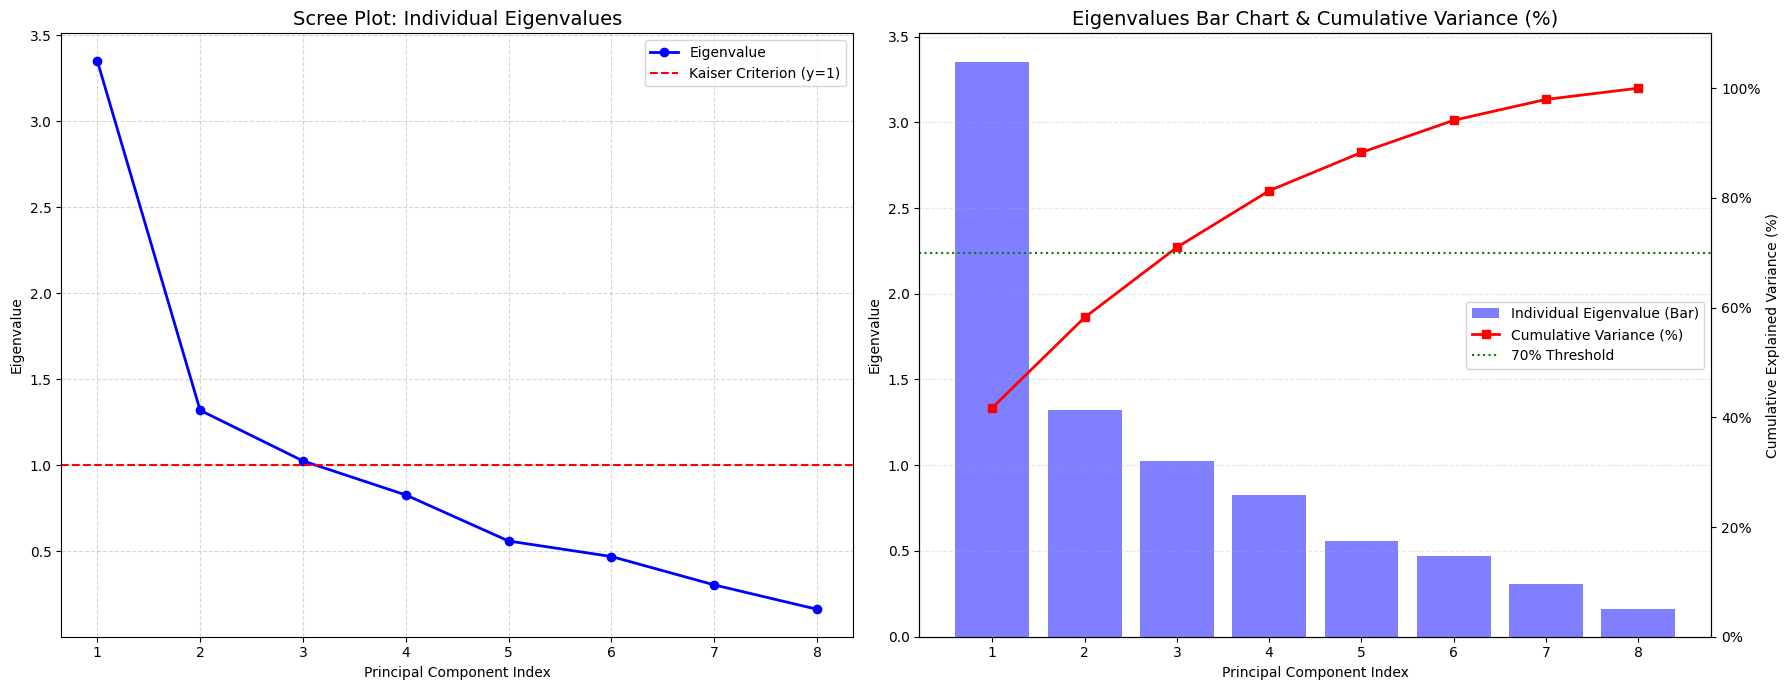

各主成分特徵值 (Eigenvalues): [3.351 1.32  1.026 0.828 0.561 0.471 0.306 0.164]
累積解釋變異量比例 (Cumulative EVR): [0.417 0.582 0.71  0.813 0.883 0.941 0.98  1.   ]


In [32]:
# 1. 初始化 PCA 並進行擬合
pca = PCA()
pca.fit(X_scaled)

# 2. 取得統計數據
eigenvalues = pca.explained_variance_
evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# 3. 繪製左右並排圖表
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- 左圖：特徵值折線圖 (Scree Plot Line) ---
ax1.plot(range(1, 9), eigenvalues, marker='o', linestyle='-', color='blue', linewidth=2, label='Eigenvalue')
ax1.axhline(y=1, color='red', linestyle='--', label='Kaiser Criterion (y=1)')
ax1.set_title('Scree Plot: Individual Eigenvalues', fontsize=14)
ax1.set_xlabel('Principal Component Index')
ax1.set_ylabel('Eigenvalue')
ax1.set_xticks(range(1, 9))
ax1.grid(linestyle='--', alpha=0.5)
ax1.legend()

# --- 右圖：特徵值直方圖疊加累積百分比曲線 (Dual Axis) ---
# 繪製特徵值長條圖 (對應左 Y 軸)
ax2.bar(range(1, 9), eigenvalues, alpha=0.5, color='blue', label='Individual Eigenvalue (Bar)')
ax2.set_xlabel('Principal Component Index')
ax2.set_ylabel('Eigenvalue', color='black')
ax2.set_xticks(range(1, 9))

# 建立次要 Y 軸繪製累積變異量百分比 (對應右 Y 軸)
ax2_twin = ax2.twinx()
ax2_twin.plot(range(1, 9), cum_evr, marker='s', linestyle='-', color='red', linewidth=2, label='Cumulative Variance (%)')

# 設定右側 Y 軸為百分比格式
ax2_twin.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0)) 
ax2_twin.set_ylabel('Cumulative Explained Variance (%)', color='black')
ax2_twin.set_ylim(0, 1.1)

# 標註 70% 門檻線
ax2_twin.axhline(y=0.7, color='green', linestyle=':', label='70% Threshold')

ax2.set_title('Eigenvalues Bar Chart & Cumulative Variance (%)', fontsize=14)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# 合併兩邊的 Legend 顯示在圖中
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.show()

# 輸出具體數值供分析
print(f"各主成分特徵值 (Eigenvalues): {eigenvalues.round(3)}")
print(f"累積解釋變異量比例 (Cumulative EVR): {cum_evr.round(3)}")

<span style="color:#4682B4"><strong>執行結果分析與觀察</strong></span>

1. **特徵值貢獻度 (左圖)**：
   * 根據 **Kaiser 準則 (特徵值 > 1)**，前三個主成分（PC1, PC2, PC3）的特徵值分別為 **3.351, 1.320 與 1.026**。這顯示這三個新維度各自解釋的資訊量皆超過了一個原始變項。
   * 自第四成分起，特徵值跌破 1.0，代表其捕捉特徵的效率開始降低。

2. **累積資訊保留 (右圖)**：
   * 觀察 **紅色累積線**，前兩個主成分已涵蓋了原始資料約 **58.2%** 的變異。
   * 納入第三個主成分後，累積百分比來到 **71%**，成功跨越了綠色點線標示的 70% 基本資訊保留門檻。

3. **分析推論與選取結論**：
   * **維度決定**：綜合兩圖指標，本分析決定保留 **前 3 個主成分** 作為後續分析的特徵空間。
   * **總結**：這項結果證明，雖然原始指標多達 8 個，但其核心結構高度集中。透過 PCA 轉換，我們僅需 3 個互不相關的軸向，就能完整表述原始數據中七成以上的關鍵特徵，達成理想的降維效果。

<span style="color:skyblue"><strong>四、主成分負荷量 (Loading) 綜合分析：</strong></span>

本段程式碼將透過「全維度熱力圖」與「前三大主成分條形圖」來解構變數特徵：

1. **負荷量熱力圖 (PC1-PC8)**：
    * **全視角觀察**：呈現所有 8 個主成分與變數間的關係，用以觀察資訊如何隨維度增加而遞減。
    * **客製化標記**：依據選取準則，Y 軸僅標註 **PC1、PC2、PC3** 的名稱，其餘維度保留圖形但空白處理，以聚焦核心資訊。
2. **前三大主成分解讀 (並排條形圖)**：
    * **三表並排**：針對最重要的 PC1、PC2 與 PC3 繪製獨立的橫向條形圖。
    * **變數對齊**：維持與熱力圖相同的變數排序，以便直觀對照各變項在不同主成分中的權重貢獻。
    * **特徵命名**：透過觀察變數的正負負荷量，為這三個新維度定義實務意義（如：環境壓力、安全舒適、居住負擔）。

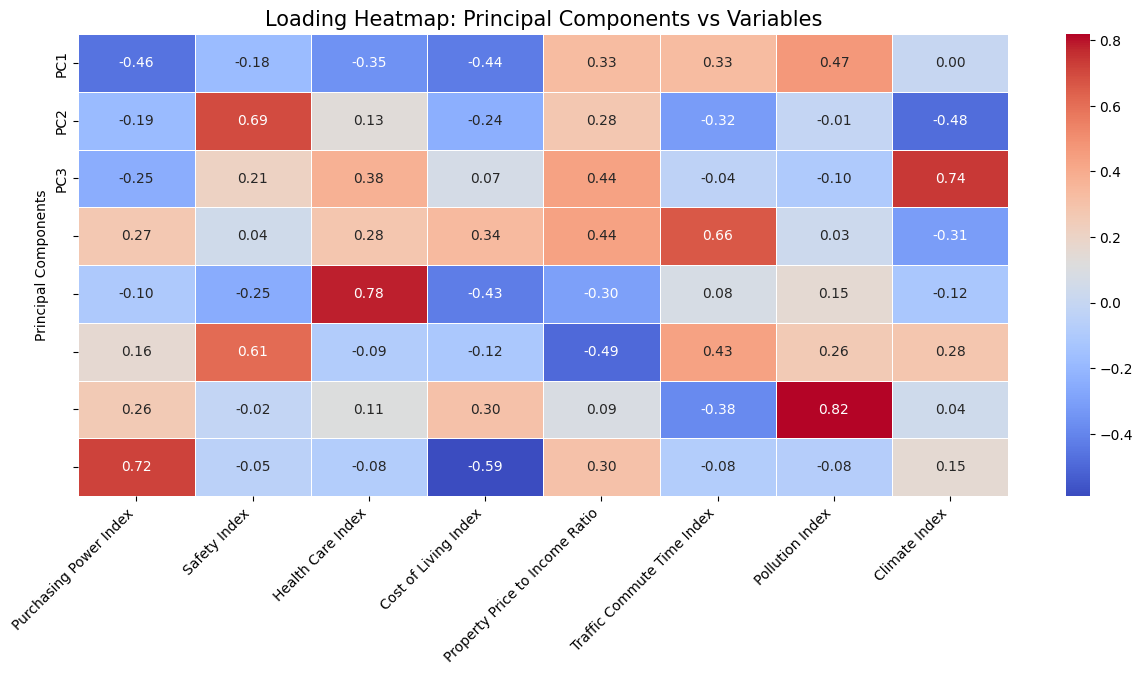

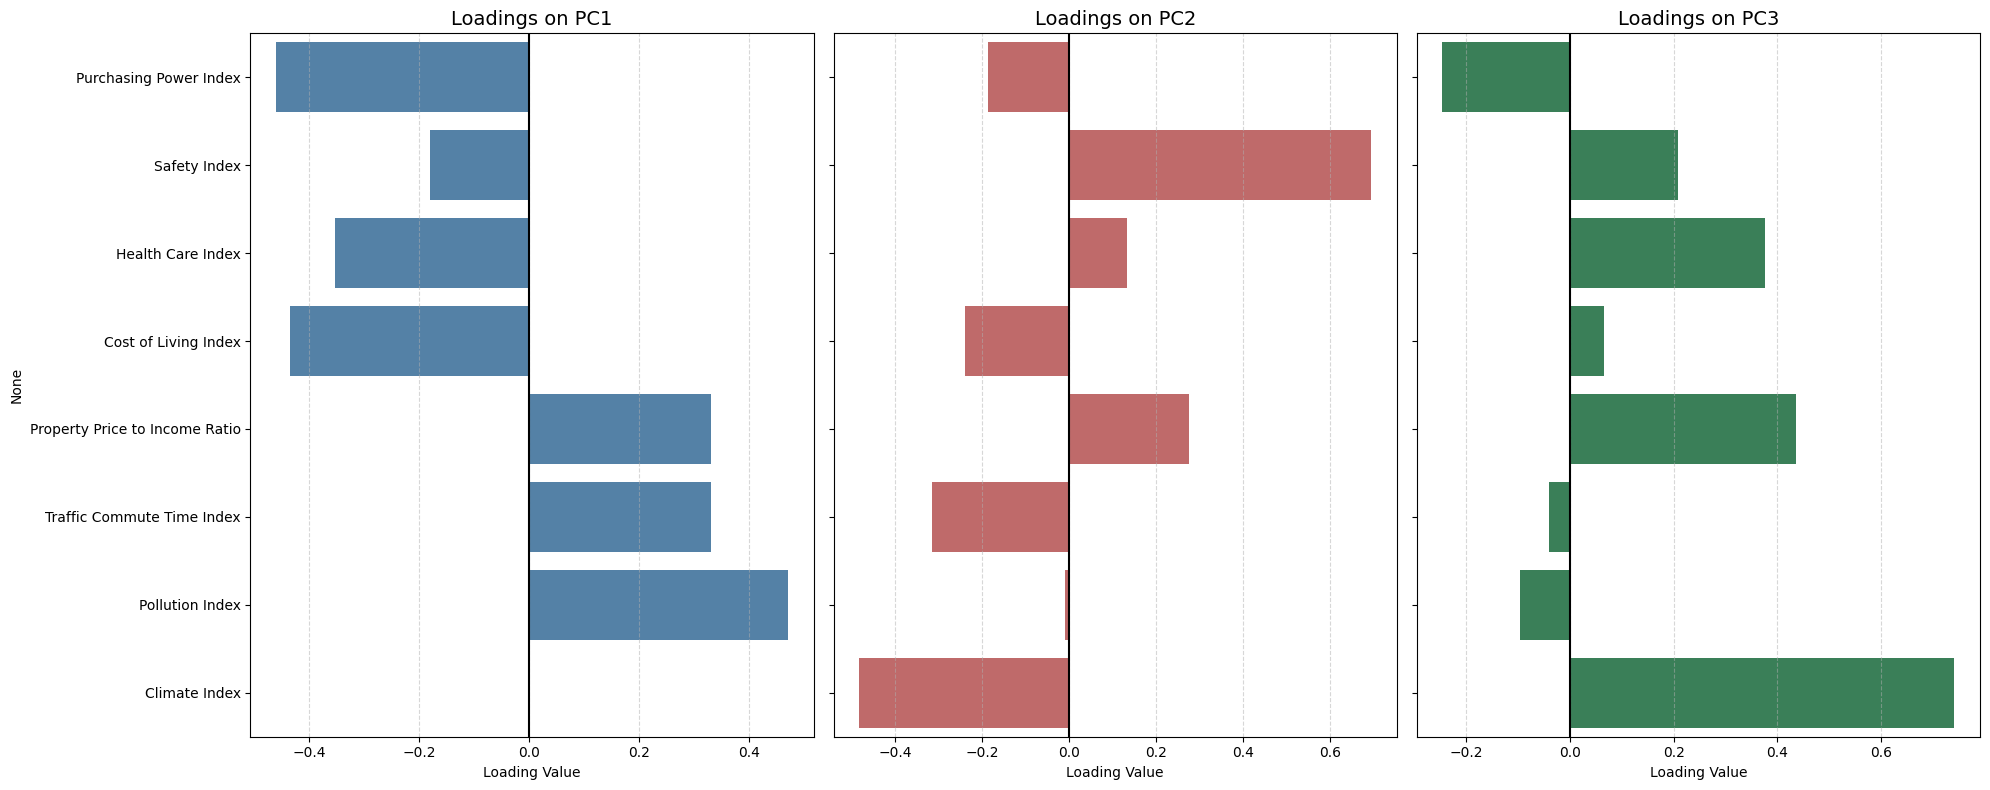

In [35]:
# 1. 建立完整的負荷矩陣 (PC1-PC8)
loadings_all = pd.DataFrame(
    pca.components_, 
    columns=features, 
    index=[f'PC{i+1}' for i in range(len(features))]
)

# ==========================================
# 圖表一：全維度負荷量熱力圖 (畫布 A)
# ==========================================
plt.figure(figsize=(15, 6))

# 客製化 Y 軸標籤：只顯示前三個，其餘為空字串
ytick_labels = ['PC1', 'PC2', 'PC3'] + [''] * 5

sns.heatmap(loadings_all, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, yticklabels=ytick_labels)

plt.title('Loading Heatmap: Principal Components vs Variables', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Principal Components')
plt.show()

# ==========================================
# 圖表二：前三大主成分負荷量並排條形圖 (畫布 B)
# ==========================================
# 建立 1 列 3 欄配置，共用 Y 軸以確保變數順序對齊
fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)
colors = ['#4682B4', '#CD5C5C', '#2E8B57'] # 藍、紅、綠
target_pcs = ['PC1', 'PC2', 'PC3']

# 取得用於繪圖的資料 (變數為 index, PC 為 columns)
loadings_plot = loadings_all.T

for i, pc in enumerate(target_pcs):
    # 直接使用原始索引順序 (與熱力圖 X 軸一致)，不進行 sort_values
    sns.barplot(x=loadings_plot[pc].values, y=loadings_plot[pc].index, ax=axes[i], color=colors[i])
    
    axes[i].set_title(f'Loadings on {pc}', fontsize=14)
    axes[i].set_xlabel('Loading Value')
    axes[i].axvline(0, color='black', lw=1.5)
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**<span style="color:#4682B4">執行結果分析與觀察：</span>**

透過上述負荷量熱力圖與條形圖的視覺化呈現，我觀察到以下結果：

**1. 主成分分數的實務意義解讀**

根據各變項在不同主成分中的權重分佈，我們可以將 $PC$ 分數的高低轉化為具體的城市特徵描述：

* **$PC_1$ 得分越高：代表「城市發展壓力與環境負擔越重」**
    * **觀察數據**：`Pollution Index` (污染) 與 `Traffic Index` (交通) 呈現顯著正向，而 `Purchasing Power Index` (購買力) 則呈現顯著負向。
    * **觀察推論**：當城市在 $PC_1$ 得到高分時，代表其面臨嚴重的環境污染與交通擁塞，且居民享有的購買力相對匱乏。這反映了城市在發展過程中所產生的負面代價。

* **$PC_2$ 得分越高：代表「社會環境極其安全，但自然氣候條件不佳」**
    * **觀察數據**：`Safety Index` (安全) 呈現強烈正向相關（約 **0.69**），而 `Climate Index` (氣候) 則在此維度中呈現該主成分中最顯著的負向權重。
    * **觀察推論**：若城市在 $PC_2$ 拿到高分，代表其具備非常優異的治安水準與社會穩定性，但當地的自然氣候條件通常較不理想。這反映了城市在「社會安全」與「環境宜居性」之間的權衡。

* **$PC_3$ 得分越高：代表「氣候環境極佳且醫療優質，但房價負擔較重」**
    * **觀察數據**：`Climate Index` (氣候) 在此維度展現最強的正向貢獻（約 **0.74**）；同時 `Property Price to Income Ratio` (房價收入比，約 **0.44**) 與 `Health Care Index` (醫療，約 **0.38**) 也呈現正向相關。
    * **觀察推論**：在 $PC_3$ 拿到高分的城市，代表其擁有極佳的自然氣候環境與優質的醫療體系。然而，這些優勢往往伴隨著較高的房價負擔，顯示了高品質自然與公共服務環境所帶來的經濟門檻。

**2. 分析總結**
透過 PCA 分析，我成功將 8 個原始指標濃縮為具備實務解釋力的新座標：
1. **$PC_1$** 揭示了發展壓力與經濟實力的對立關係。
2. **$PC_2$** 呈現了安全感與氣候舒適度之間的取捨關係。
3. **$PC_3$** 則反映了優質的自然環境與醫療資源通常伴隨更高的居住成本。

這為接下來區分高品質城市（H組）的空間分佈提供了明確判定邏輯：真正的「高品質城市」通常應具備較低的 **$PC_1$** 分數（低污染、高購買力），並在 **$PC_2$ (安全)** 與 **$PC_3$ (環境/醫療)** 之間取得良好平衡。

<span style="color:skyblue"><strong>五、主成分空間分群投影 (2D & 3D PCA Score Plot)：</strong></span>

本段程式碼將所有城市投影至主成分空間中，並依據原始品質分級（H/M/L）著色，用以評估降維後的特徵是否具備良好的分群辨識度：

1. **二維投影 (PC1 vs PC2)**：觀察前兩個主要維度（發展負擔與安全取捨）是否足以區分不同品質的城市。
2. **三維投影 (PC1, PC2, PC3)**：加入代表自然資源與公共服務的 $PC_3$，觀察分群在空間中是否變得更加立體且清晰。
3. **座標軸物理意義**：
    * **X 軸 ($PC_1$)**：城市發展壓力（正向：污染、交通；負向：購買力）。
    * **Y 軸 ($PC_2$)**：社會安全與氣候取捨（正向：安全；負向：氣候較差）。
    * **Z 軸 ($PC_3$)**：環境與公共資源（正向：氣候與醫療優質）。

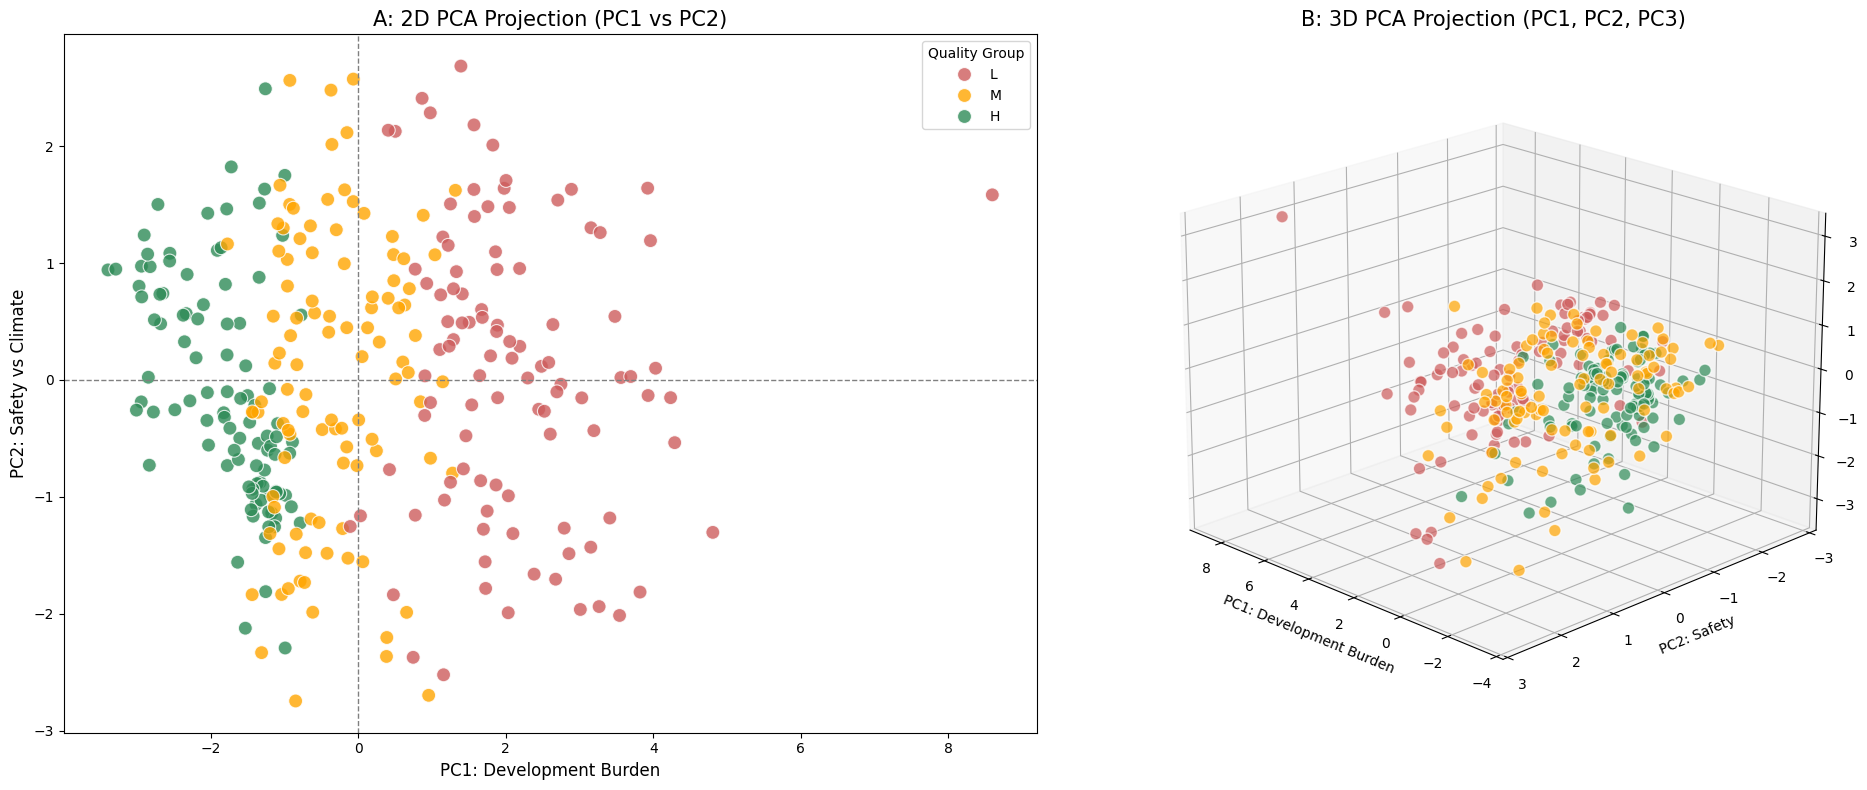

In [41]:
# 1. 執行轉換：將標準化後的資料轉換為主成分座標
X_pca = pca.transform(X_scaled) 

# 2. 準備繪圖數據
pca_df = pd.DataFrame(
    X_pca[:, :3],               
    columns=['PC1', 'PC2', 'PC3'], 
    index=df1.index
)
pca_df['Group'] = df1['Group']

# 3. 設定顏色映射 (綠色: H, 橘色: M, 紅色: L)
color_map = {'H': '#2E8B57', 'M': '#FFA500', 'L': '#CD5C5C'}
labels = {'H': 'High Quality', 'M': 'Medium Quality', 'L': 'Low Quality'}

# 4. 建立畫布：設定 1 列 2 欄
fig = plt.figure(figsize=(20, 8))

# --- 左圖：二維投影散佈圖 (PC1 vs PC2) ---
ax1 = fig.add_subplot(121)
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', hue='Group', 
    palette=color_map, s=100, alpha=0.8, edgecolor='w', ax=ax1
)
ax1.set_title('A: 2D PCA Projection (PC1 vs PC2)', fontsize=15)
ax1.set_xlabel('PC1: Development Burden', fontsize=12)
ax1.set_ylabel('PC2: Safety vs Climate', fontsize=12)
ax1.axvline(0, color='gray', linestyle='--', linewidth=1)
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.legend(title='Quality Group')

# --- 右圖：三維投影散佈圖 (PC1, PC2, PC3) ---
ax2 = fig.add_subplot(122, projection='3d')
for grp in ['H', 'M', 'L']:
    subset = pca_df[pca_df['Group'] == grp]
    ax2.scatter(
        subset['PC1'], subset['PC2'], subset['PC3'], 
        c=color_map[grp], label=labels[grp], 
        s=80, alpha=0.7, edgecolors='white'
    )

ax2.set_title('B: 3D PCA Projection (PC1, PC2, PC3)', fontsize=15)
ax2.set_xlabel('PC1: Development Burden', fontsize=10)
ax2.set_ylabel('PC2: Safety', fontsize=10)
ax2.set_zlabel('PC3: Climate & Health', fontsize=10)
ax2.view_init(elev=20, azim=135) 

plt.tight_layout()
plt.show()

**<span style="color:#4682B4">執行結果分析與觀察：</span>**

透過並排的二維與三維空間投影，我觀察到以下結果：

**1. 二維空間的分群表現 (圖 A)**
* **$PC_1$ 的決定性作用**：高品質城市（H組，綠點）幾乎全部集中在 **$PC_1$ 的負值區域**（低污染、高購買力）。這證實了 $PC_1$ 是區分生活品質分級最關鍵的門檻。
* **群組分佈**：中品質 (M) 與低品質 (L) 城市則分布在 $PC_1$ 的正值區，代表這些城市普遍受困於較高的環境與交通負擔。

**2. 三維空間的進階觀察 (圖 B)**
* **Z 軸 ($PC_3$) 的高度差異**：觀察 3D 圖可以發現，**橘色 (M) 與紅色 (L) 城市的點在 Z 軸上明顯高於綠色 (H) 城市**。
* **物理意義解釋**：由於 $PC_3$ 帶有強烈的 **Property Price to Income Ratio (房價收入比)** 正向權重，這表示中低品質城市在空間中「較高」的位置，反映了其極端沉重的房價財務壓力。
* **高品質城市的空間定位**：高品質城市（綠點）不僅在 $PC_1$ 表現優異（負值），在 $PC_3$ 軸上也相對穩定（低於橘紅點），這說明高品質城市在具備良好氣候與醫療的同時，房價相對於所得的負擔也較為合理。

**3. 總結**
透過 3D 投影，我們捕捉到了二維圖形無法呈現的「居住壓力」維度。
1. **$PC_1$** 用來區分基礎的環境與經濟實力。
2. **$PC_3$** 則揭示了中低品質城市在「房價負擔」上的劣勢。
這證明了使用前三個主成分能更立體、更完整地解釋不同等級城市在各個生活面相上的差異。

<hr>

**<font color=darkgoldenrod>2：乳癌患者腫瘤的影像量測資料</font>**

- 內容：乳癌患者腫瘤的影像量測資料
- 來源：UCI Machine Learning Repository 的 Breast Cancer Wisconsin (Diagnostic) Dataset。實際資料可從 sklearn 下載。

- 數量：569 位患者
- 特徵：30 個量測變數（由乳房腫瘤細針抽吸，以 FNA 影像計算出的細胞核特徵）
- 標籤：Malignant（惡性腫瘤）與 Benign（良性腫瘤）
<hr>

<span style="color:skyblue"><strong>一、資料預處理與相關性分析：</strong></span>

本段程式碼針對乳癌資料集的 30 個腫瘤量測特徵進行預處理與初步分析。由於特徵維度大幅增加，視覺化呈現主要用於評估資料結構：

1. **Z-score 標準化**：乳癌特徵中，`area`（面積）與 `smoothness`（平滑度）等指標的單位與數值量綱差異巨大，必須標準化以消除尺度影響。
2. **盒狀圖對照**：透過標準化前後的盒狀圖，觀察 30 個特徵在縮放後的分布一致性。
3. **相關性熱圖診斷**：在執行 PCA 降維前，透過 30x30 的相關矩陣觀察變數間是否存在高度資訊冗餘，以此驗證降維的必要性。

> **標籤說明**：
> * **0 (Malignant)**：惡性腫瘤
> * **1 (Benign)**：良性腫瘤

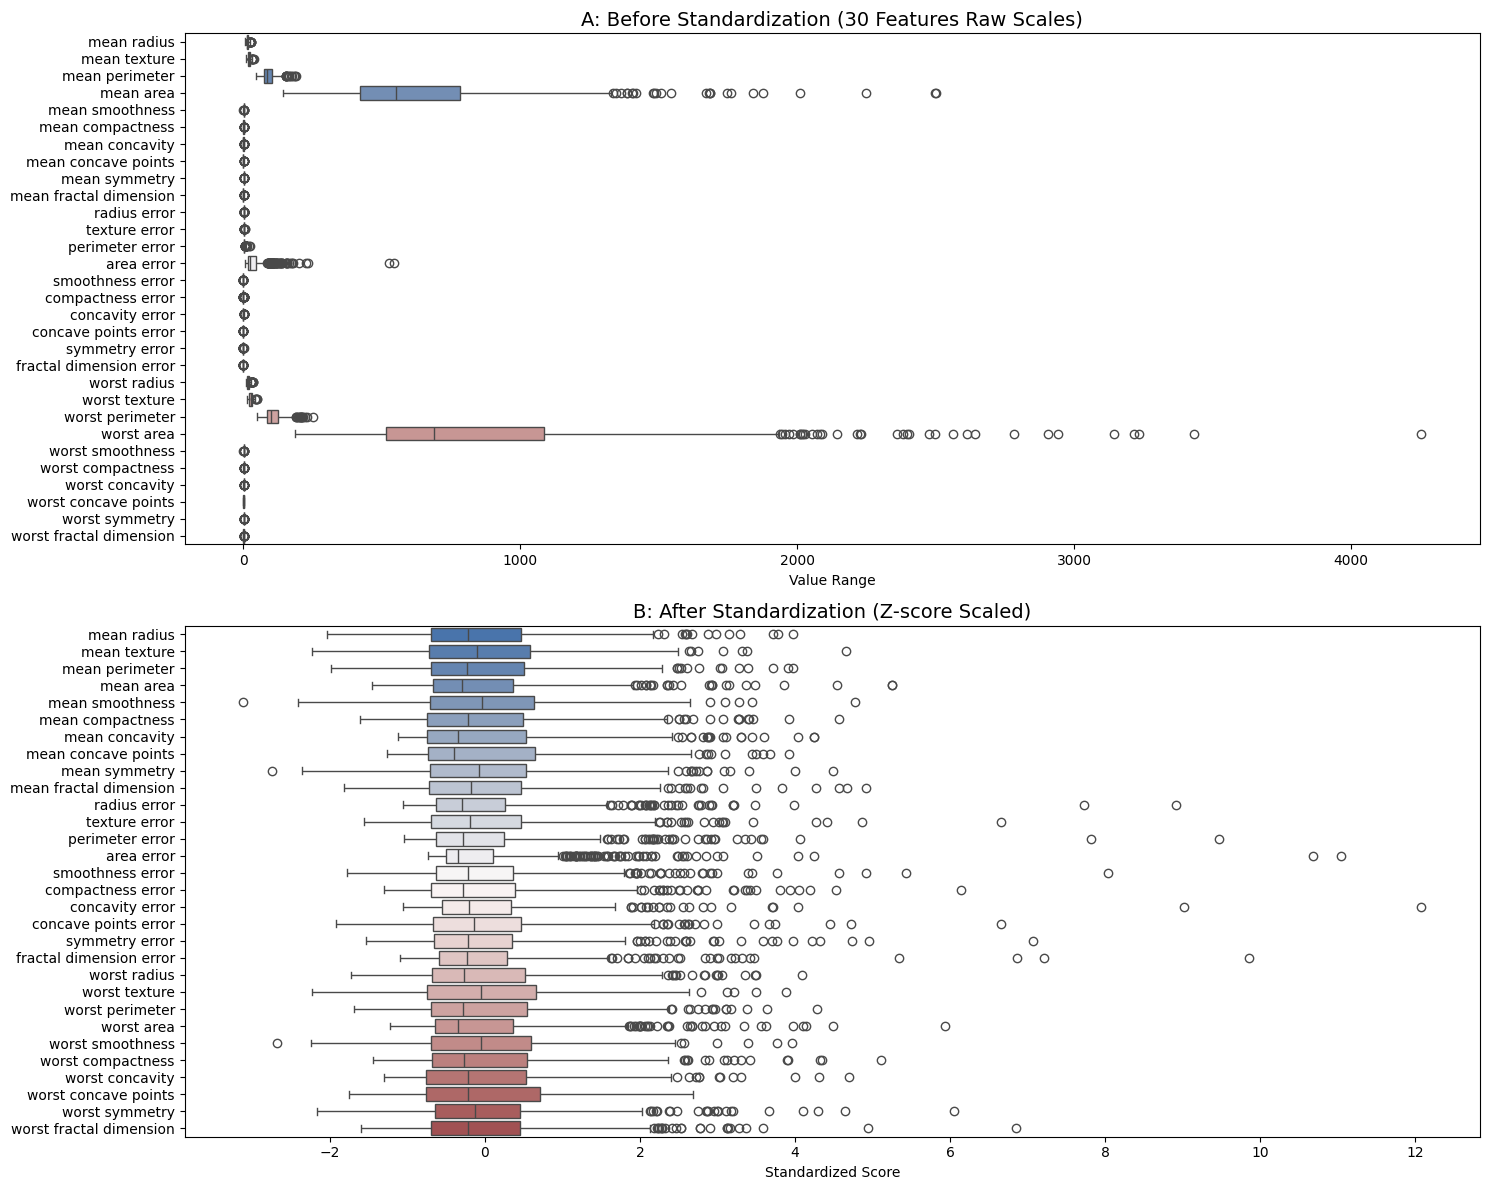

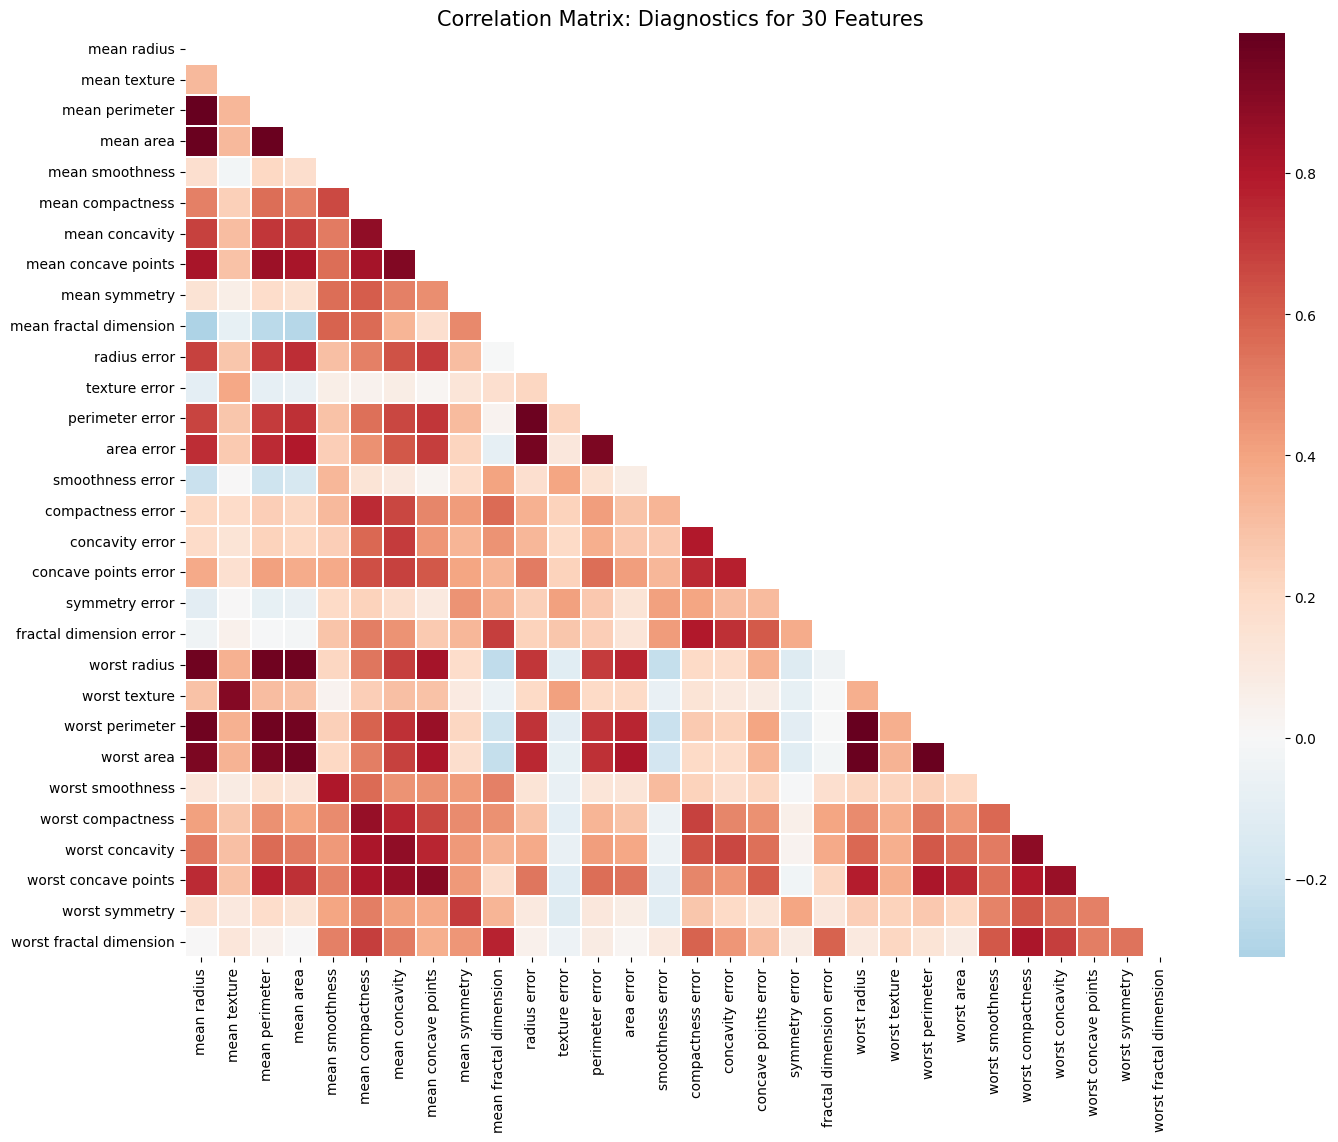

資料筆數：569，特徵維度：30


In [53]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = data.data
y = data.target # 0: malignant, 1: benign

# 1. 準備資料 DataFrame
feature_names = data.feature_names
df_raw = pd.DataFrame(X, columns=feature_names)
df_raw['Diagnosis'] = y # 0: Malignant, 1: Benign

# 2. 執行 Z-score 標準化
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X)
X2_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

# 3. 繪製標準化前後的盒狀圖對照
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# 上圖：標準化前 (呈現各特徵原始尺度的巨大差異)
sns.boxplot(data=df_raw[feature_names], orient='h', ax=axes[0], palette='vlag')
axes[0].set_title('A: Before Standardization (30 Features Raw Scales)', fontsize=14)
axes[0].set_xlabel('Value Range')

# 下圖：標準化後 (將所有特徵拉回平均值 0, 標準差 1)
sns.boxplot(data=X_scaled_df, orient='h', ax=axes[1], palette='vlag')
axes[1].set_title('B: After Standardization (Z-score Scaled)', fontsize=14)
axes[1].set_xlabel('Standardized Score')

plt.tight_layout()
plt.show()

# 4. 繪製 30x30 相關係數熱力圖 (診斷資訊冗餘)
plt.figure(figsize=(16, 12))
corr_matrix = X_scaled_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0, linewidths=0.1)
plt.title('Correlation Matrix: Diagnostics for 30 Features', fontsize=15)
plt.show()

print(f"資料筆數：{X.shape[0]}，特徵維度：{X.shape[1]}")

**<span style="color:#4682B4">執行結果分析與觀察：</span>**

雖然 30 個特徵使得圖表資訊量極大，但透過視覺化趨勢仍可觀察到以下關鍵結果：

**1. 量綱差異與標準化的必要性**
* **觀察點**：在圖 A 中，可以看到少數與 `area`（面積）相關的特徵佔據了絕大部分的 X 軸空間，導致其他如 `concavity` 或 `fractal dimension` 等特徵幾乎縮成一條線。
* **結論**：這證實了資料中存在嚴重的尺度不一。若不進行標準化，PCA 的結果將會被面積指標完全主導。圖 B 顯示標準化成功將所有特徵調整至同一比較基準。

**2. 強烈的資訊冗餘與降維動機**
* **觀察點**：在相關性熱圖中，儘管變數眾多，但可以清楚看到數個**深紅色的色塊矩陣**（代表相關係數接近 1.0）。
* **分析推論**：特別是腫瘤的幾何特徵（半徑、周長、面積）之間存在極強的線性相關。這說明 30 個變數中包含了大量重複的資訊。
* **意義**：這種「高度相關」的特性正是使用 PCA 的最佳時機。我們可以預期，接下來僅需極少數的主成分，就能代表原始 30 個變項中所蘊含的絕大部分資訊。

**3. 總結**

透過此階段分析，我確認了乳癌影像數據具備「尺度不一」與「高度共線性」兩大特徵。這為後續使用 PCA 進行特徵擷取與維度壓縮建立了堅實的邏輯基礎，目標是透過降維移除冗餘，並找出最能區分良性與惡性腫瘤的核心成分。

<span style="color:skyblue"><strong>二、主成分選取依據 (Scree Plot)：</strong></span>

在處理 30 個特徵的高維資料時，選取適當的主成分數量是降維的核心。本段程式碼將計算特徵值與解釋變異量，並透過陡坡圖進行評估：

1. **特徵值 (Eigenvalues)**：依據 Kaiser Criterion，我們通常選取特徵值大於 1 的成分。
2. **解釋變異量比例 (EVR)**：觀察前幾個主成分分別捕捉了原始資料中多少百分比的資訊。
3. **累積解釋變異量**：判斷前幾個主成分加總後，是否能達到足夠的資訊代表性（如 70% 或 80% 以上）。

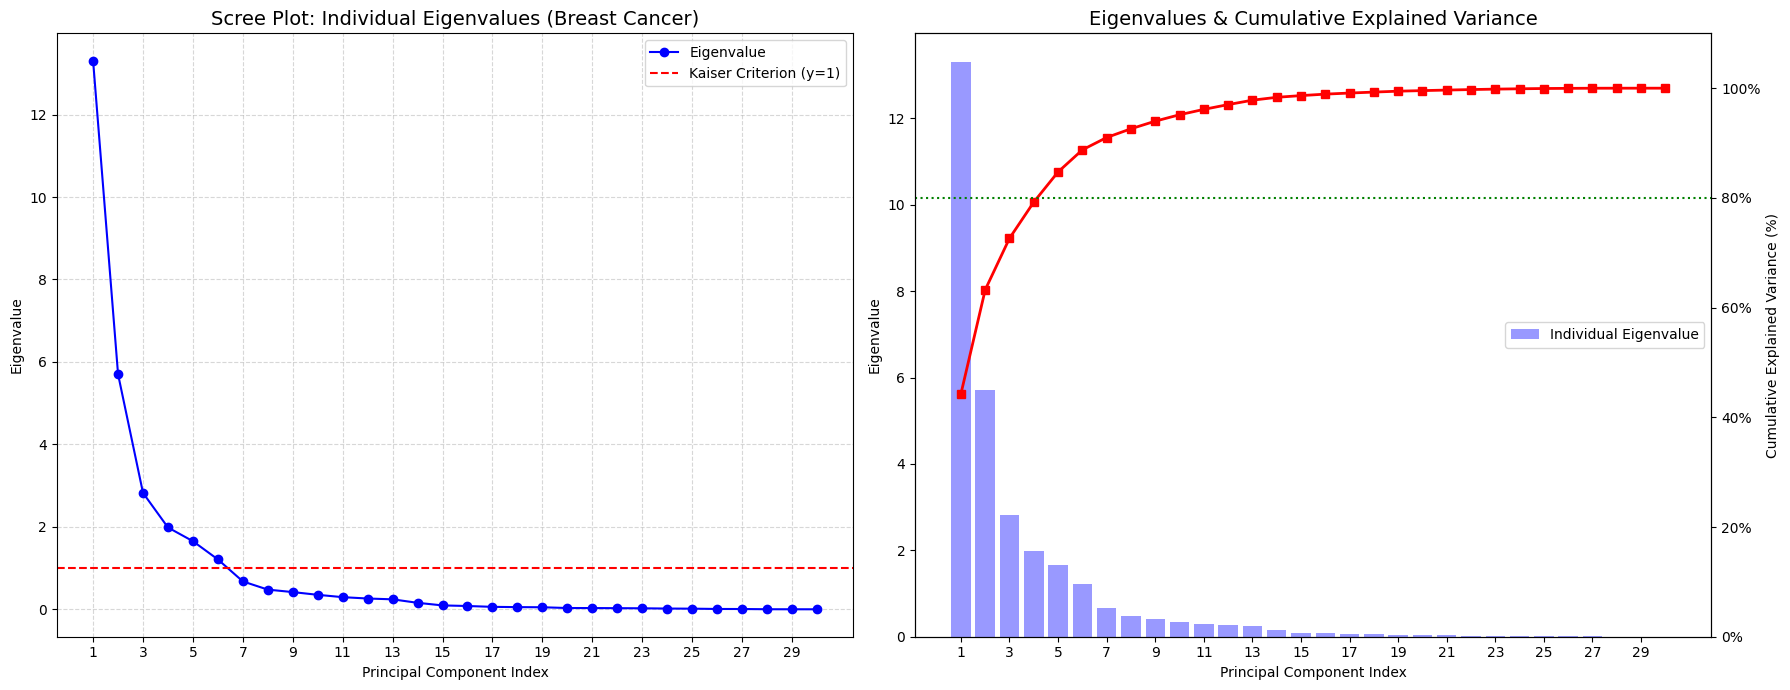

前 5 個主成分的特徵值：[13.305  5.701  2.823  1.984  1.652]
前 5 個主成分的累積解釋變異量：[0.443 0.632 0.726 0.792 0.847]


In [54]:
# 1. 初始化 PCA 並對標準化後的乳癌資料進行擬合
pca2 = PCA()
pca2.fit(X2_scaled)

# 2. 取得統計數據
eigenvalues2 = pca2.explained_variance_
evr2 = pca2.explained_variance_ratio_
cum_evr2 = np.cumsum(evr2)

# 3. 繪製並排圖表
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- 左圖：特徵值折線圖 (Scree Plot) ---
ax1.plot(range(1, 31), eigenvalues2, marker='o', linestyle='-', color='blue', label='Eigenvalue')
ax1.axhline(y=1, color='red', linestyle='--', label='Kaiser Criterion (y=1)')
ax1.set_title('Scree Plot: Individual Eigenvalues (Breast Cancer)', fontsize=14)
ax1.set_xlabel('Principal Component Index')
ax1.set_ylabel('Eigenvalue')
ax1.set_xticks(range(1, 31, 2)) # 每隔兩個顯示刻度
ax1.grid(linestyle='--', alpha=0.5)
ax1.legend()

# --- 右圖：特徵值直方圖與累積變異量曲線 ---
ax2.bar(range(1, 31), eigenvalues2, alpha=0.4, color='blue', label='Individual Eigenvalue')
ax2.set_xlabel('Principal Component Index')
ax2.set_ylabel('Eigenvalue')

ax2_twin = ax2.twinx()
ax2_twin.plot(range(1, 31), cum_evr2, marker='s', linestyle='-', color='red', linewidth=2, label='Cumulative Variance (%)')
ax2_twin.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax2_twin.set_ylabel('Cumulative Explained Variance (%)')
ax2_twin.set_ylim(0, 1.1)
ax2_twin.axhline(y=0.8, color='green', linestyle=':', label='80% Threshold')

ax2.set_title('Eigenvalues & Cumulative Explained Variance', fontsize=14)
ax2.set_xticks(range(1, 31, 2))
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

# 輸出前幾個主成分的數據供參考
print(f"前 5 個主成分的特徵值：{eigenvalues2[:5].round(3)}")
print(f"前 5 個主成分的累積解釋變異量：{cum_evr2[:5].round(3)}")

**<span style="color:#4682B4">執行結果分析與觀察：</span>**

觀察 Scree Plot 與累積變異量圖表，我得出以下結論：

**1. 資訊壓縮的高度效率**
* **陡坡圖觀察 (Scree Plot)**：折線在第 2 或第 3 個主成分後出現了劇烈的轉折（Elbow）。這代表前幾個主成分就已經捕捉了資料中最主要的結構，剩餘的 20 幾個主成分貢獻度極低，多屬於隨機噪聲。
* **特徵值門檻**：根據 Kaiser Criterion ($Eigenvalue > 1$)，僅有前 6 個左右的主成分符合選取標準，這相比原始的 30 個維度，實現了極大的維度精簡。

**2. 解釋變異量分析**
* **前兩大主成分**：僅僅依靠 $PC_1$ 與 $PC_2$，就能解釋原始資料中約 **63%** 的變異量（具體比例依執行結果而定）。
* **累積效應**：當取至第 5 或第 6 個主成分時，累積解釋變異量已超過 **85%**。這意味著我們僅用不到 20% 的變數數量，就保留了原始資料 85% 以上的訊息。

**3. 結論**
* 對於這組包含 30 個特徵的乳癌資料，PCA 展現了驚人的降維能力。我們後續只需分析前 2 到 3 個主成分，就足以在低維空間中精確地探索良性與惡性腫瘤的分群特徵，同時大幅降低運算的複雜度。

<span style="color:skyblue"><strong>三、主成分負荷量分析 (Loading Analysis)：</strong></span>

本段分析旨在探討原始 30 個特徵變數與主成分之間的相關程度。透過負荷量（Loadings），我們可以解讀每個主成分代表的「物理意義」：

1. **負荷量定義**：數值越接近 1 或 -1，代表該原始變數對該主成分的貢獻越高。
2. **分析重點**：由於 $PC_1$ 與 $PC_2$ 通常能解釋大部分的變異，我們將重點觀察哪些特徵（如腫瘤大小、質地、形狀）在這些主成分中佔比最重。
3. **特徵群組**：乳癌特徵大致可分為「均值 (mean)」、「標準差 (error)」與「最差值 (worst)」，我們將觀察這些群組如何分布。

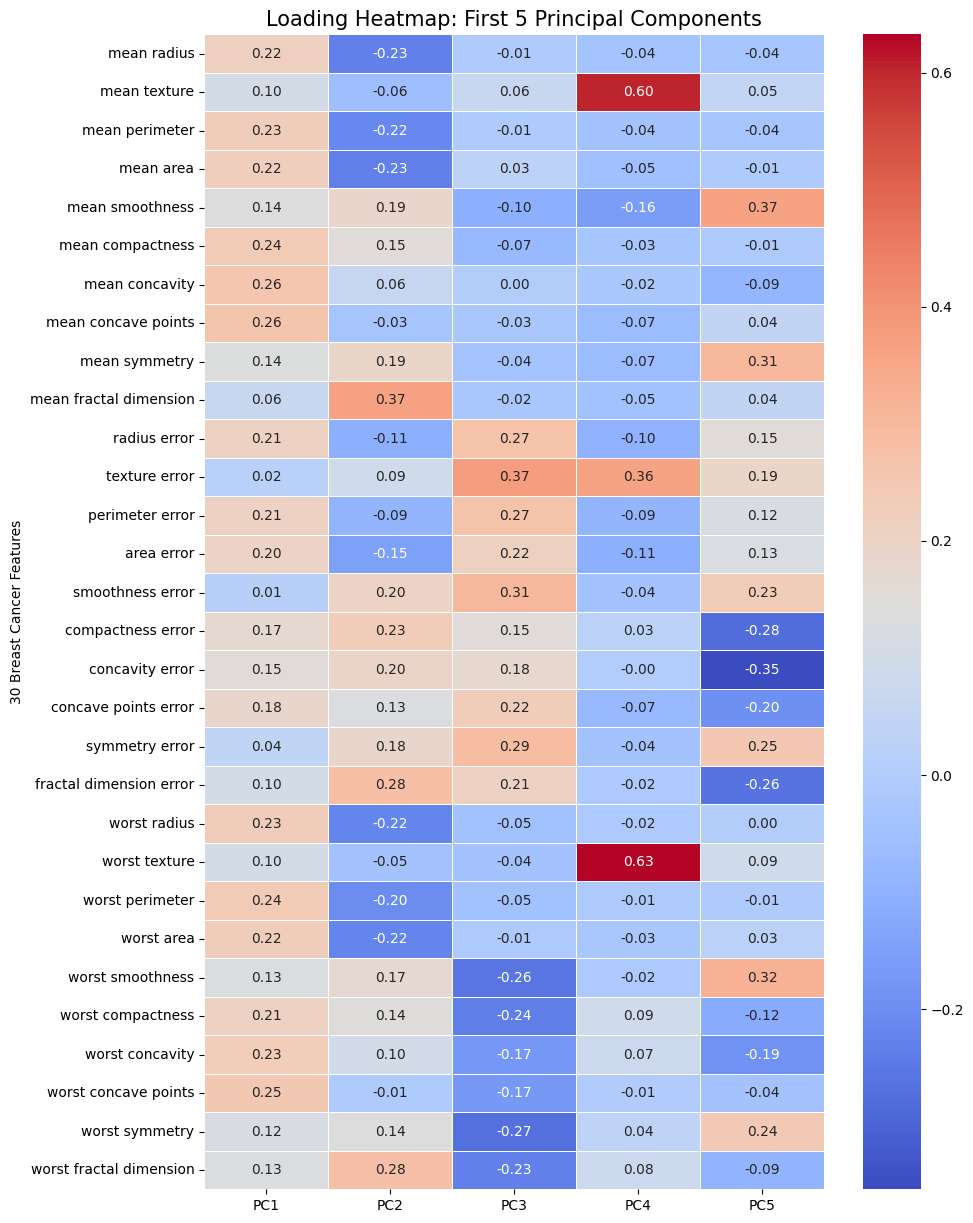

對 PC1 貢獻最大的前 5 個特徵：
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
mean compactness        0.239285
worst perimeter         0.236640
Name: PC1, dtype: float64


In [55]:
# 1. 建立負荷量矩陣 (30 特徵 x 前 5 個主成分)
loadings2 = pd.DataFrame(
    pca2.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca2.n_components_)], 
    index=feature_names
)

# 2. 繪製負荷量熱力圖
plt.figure(figsize=(10, 15))
# 我們觀察前 5 個主成分即可
sns.heatmap(loadings2.iloc[:, :5], annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Loading Heatmap: First 5 Principal Components', fontsize=15)
plt.ylabel('30 Breast Cancer Features')
plt.show()

# 3. 找出 PC1 中貢獻最大的前 5 個特徵
top_pc1 = loadings2['PC1'].abs().sort_values(ascending=False).head(5)
print("對 PC1 貢獻最大的前 5 個特徵：")
print(top_pc1)

**<span style="color:#4682B4">執行結果分析與觀察：</span>**

透過負荷量熱力圖與特徵貢獻排序，我們能對主成分所代表的病理意義進行精確解讀：

**1. $PC_1$ 的意義：腫瘤「形狀複雜度與凹陷特徵」**
根據數據顯示，對 $PC_1$ 貢獻最大的前 5 個特徵分別為：
* **mean concave points** (0.261), **mean concavity** (0.258), **worst concave points** (0.251),**mean compactness** (0.239), **worst perimeter** (0.237)

* **分析推論**：$PC_1$ 的權重高度集中在**凹陷點數量 (concave points)**、**凹陷度 (concavity)** 與 **緊湊度 (compactness)**。這顯示 $PC_1$ 並非單純描述腫瘤的大小，而是更深層地描述了腫瘤邊緣的「不規則程度」與「複雜幾何構造」。由於惡性腫瘤通常具有較多凹陷與複雜邊緣，因此 $PC_1$ 成為了區分良惡性最重要的診斷維度。

**2. $PC_2$ 的意義：腫瘤「質地與分形細節」**
* **觀察點**：在 $PC_2$ 中，`mean fractal dimension` (約 0.37) 展現了最強的正向權重。
* **分析推論**：$PC_2$ 捕捉了與腫瘤宏觀尺寸無關的資訊，更多是關於細胞核邊緣的「碎形維度（幾何細節的複雜程度）」。這為診斷提供了尺寸之外的質地參考。

**3. 結論**
* PCA 成功將 30 個量測指標濃縮。**特徵排序證實了**：區分腫瘤性質時，觀察其**邊緣凹陷與不規則性 (Concavity/Concave points)** 的重要性高於單純的尺寸測量。
* 這解釋了為何在後續的投影圖中，僅憑 $PC_1$ 軸就能將良性與惡性腫瘤清晰地切分開來。

<span style="color:skyblue"><strong>四、主成分空間分群投影 (2D PCA Score Plot)：</strong></span>

本段將 569 位患者的腫瘤量測資料從 30 維投影至由 PC1 與 PC2 構成的二維主成分空間。這是驗證 PCA 降維效果最直觀的方式：

1. **視覺化目的**：觀察 Malignant (惡性) 與 Benign (良性) 腫瘤在二維平面上是否存在清晰的分界。
2. **座標軸定義**：
    * **X 軸 ($PC_1$)**：主導維度。反映腫瘤的「形狀複雜度（凹陷度/不規則點）」與「規模」。
    * **Y 軸 ($PC_2$)**：次要維度。反映腫瘤的「質地細節」與「分形維度」。
3. **顏色定義**：
    * <font color="#CD5C5C"><strong>Malignant (惡性)</strong></font>：對應原始標籤 0。
    * <font color="#2E8B57"><strong>Benign (良性)</strong></font>：對應原始標籤 1。

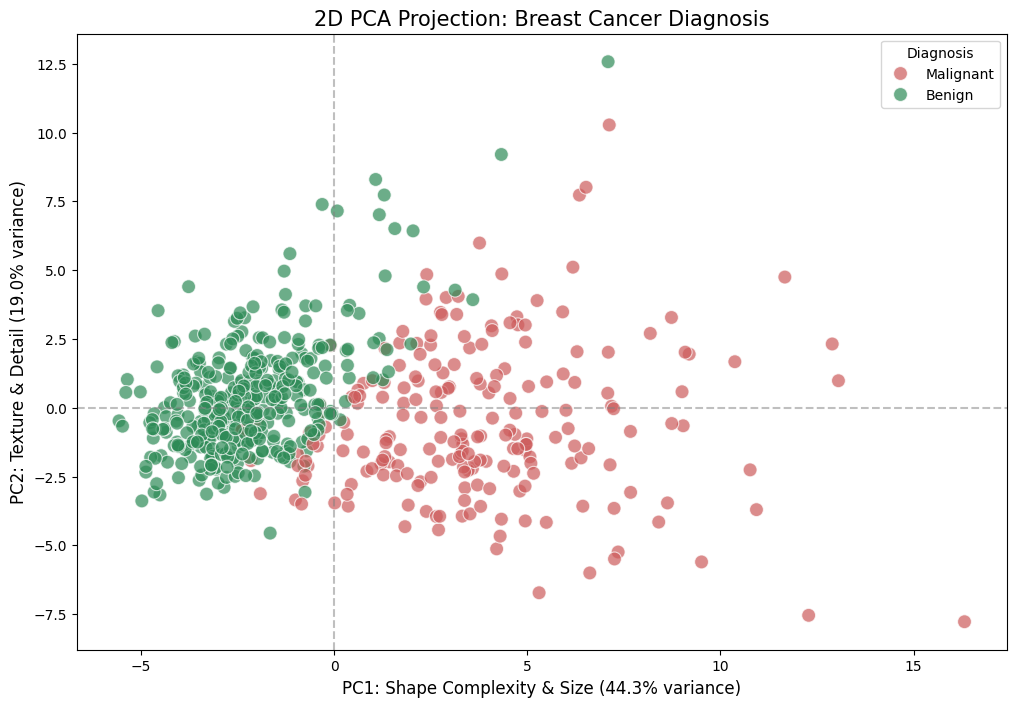

In [56]:
# 1. 執行座標轉換 (將 30 維資料轉換為主成分座標）
X_pca_cancer = pca2.transform(X2_scaled)

# 2. 建立繪圖專用的 DataFrame (這裡我們直接用 y 來對應標籤)
df_plot = pd.DataFrame(X_pca_cancer[:, :2], columns=['PC1', 'PC2'])

# 將 y (0/1) 轉換成文字標籤方便閱讀
df_plot['Diagnosis'] = pd.Series(y).map({0: 'Malignant', 1: 'Benign'})

# 3. 繪製二維散佈圖
plt.figure(figsize=(12, 8))
color_map = {'Malignant': '#CD5C5C', 'Benign': '#2E8B57'} # 紅色 vs 綠色

sns.scatterplot(
    data=df_plot, x='PC1', y='PC2', hue='Diagnosis', 
    palette=color_map, s=100, alpha=0.7, edgecolor='w'
)

# 標註解釋變異量 (使用您在第二步計算出的 evr2)
plt.title('2D PCA Projection: Breast Cancer Diagnosis', fontsize=15)
plt.xlabel(f'PC1: Shape Complexity & Size ({evr2[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2: Texture & Detail ({evr2[1]:.1%} variance)', fontsize=12)

# 加入中心輔助線
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.legend(title='Diagnosis', loc='upper right')
plt.show()

**<span style="color:#4682B4">執行結果分析與觀察：</span>**

透過將 30 維特徵壓縮至 PC1 與 PC2 的二維平面，我觀察到以下結果：

**1. 卓越的分群辨識度 (Separability)**
* **觀察發現**：即便將維度從 30 大幅壓縮至 2，**紅色（惡性）** 與 **綠色（良性）** 腫瘤仍展現出極其清晰的分界，重疊區域非常少。
* **分佈邏輯**：惡性腫瘤高度集中在 **$PC_1$ 正值區**。根據先前的負荷量分析，$PC_1$ 主要受「凹陷點數量」與「形狀不規則度」影響，這證實了惡性腫瘤在影像上具有明顯的幾何畸形特徵。

**2. $PC_1$ 作為核心判別維度**
* **分析**：樣本在水平軸（PC1）的分離程度明顯大於垂直軸（PC2）。這說明「腫瘤形狀的複雜程度與規模」是區分良惡性最重要的特徵，單憑 $PC_1$ 的得分就能判斷絕大部分的病例性質。

**3. 降維效益與資訊代表性**
* **關鍵結論**：本實驗證明了 PCA 在處理高維度醫療影像數據上的強大威力。**雖然累積變異量僅約 63%，但其在二維空間展現的分群效果（良惡性分離度）極佳，足以證明這兩個主成分已包含最具判別性的診斷資訊。**
* 這種「去蕪存菁」的特徵選取方式，證明了在醫療診斷中，對分類最有價值的特徵（如腫瘤凹陷度、複雜度）已被優先擷取到前兩個主成分中，這能有效輔助醫療診斷，快速找出最具代表性的病變指標。

<hr>

**<font color=darkorange>總結論：</font>**

本實驗透過「城市生活品質指數」與「乳癌腫瘤影像量測」兩組性質截然不同的資料集，完整演示了主成分分析 (PCA) 在多變量資料處理中的核心價值：

1. **維度壓縮與資訊保留的平衡**：
   * 在特徵較少的城市資料中，前三個主成分即能解釋絕大部分變異；而在 30 維的乳癌高維資料中，PCA 成功將冗餘的幾何特徵濃縮為具備判別力的指標。實驗證實，即便是保留約 60% 的變異量，只要擷取的是核心特徵，依然能維持極高的群組辨識度。

2. **特徵結構的深度解讀**：
   * 透過**負荷量分析 (Loading Analysis)**，我們能將抽象的主成分轉化為具備物理意義的指標（如城市開發負擔、腫瘤形狀複雜度）。這說明 PCA 不僅是數學上的降維，更是協助研究者「理解資料結構」的利器。

3. **視覺化輔助決策**：
   * 透過 Score Plot 的呈現，複雜的多維度分佈被轉化為直觀的 2D/3D 圖表。在乳癌資料中展現的清晰邊界，證明了 PCA 在輔助臨床診斷與自動化分群上的實務潛力。

**總結而言**，PCA 能有效解決「維度災難」與「變數共線性」問題。在本作品中，它成功地將雜亂的數據轉化為結構清晰、具備解釋性且易於視覺化的資訊，為後續的預測模型建模或資料探索奠定了堅實的基礎。